In [1]:
from google.colab import drive
drive.mount('/content/drive')

Mounted at /content/drive


In [2]:
import os
import cv2
import numpy as np
import matplotlib.pyplot as plt
from tqdm import tqdm

import torch
import torch.nn as nn
from torch.utils.data import Dataset, DataLoader

import albumentations as A
from albumentations.pytorch import ToTensorV2

In [3]:
DATA_PATH = "/content/drive/MyDrive/satellite-project/Data/DubaiDataset"

In [4]:
import os

print(os.listdir(DATA_PATH))

['classes.json', 'Tile 7', 'Tile 6', 'Tile 5', 'Tile 1', 'Tile 2', 'Tile 8', 'Tile 3', 'Tile 4']


In [5]:
tile_path = os.path.join(DATA_PATH, "Tile 1")
print(os.listdir(tile_path))

['images', 'masks']


In [6]:


images = []
masks = []

for tile in os.listdir(DATA_PATH):
    tile_path = os.path.join(DATA_PATH, tile)

    if not os.path.isdir(tile_path):
        continue

    img_dir = os.path.join(tile_path, "images")
    mask_dir = os.path.join(tile_path, "masks")

    if not os.path.exists(img_dir) or not os.path.exists(mask_dir):
        continue

    for img_name in sorted(os.listdir(img_dir)):  #  sorted
        img_path = os.path.join(img_dir, img_name)
        mask_path = os.path.join(mask_dir, img_name.replace(".jpg", ".png"))

        if not os.path.exists(mask_path):  # check mask
            continue

        image = cv2.imread(img_path)
        mask = cv2.imread(mask_path)

        if image is None or mask is None:
            continue

        #  convert to RGB
        image = cv2.cvtColor(image, cv2.COLOR_BGR2RGB)
        mask = cv2.cvtColor(mask, cv2.COLOR_BGR2RGB)

        images.append(image)
        masks.append(mask)

print("Total images:", len(images))
print("Total masks:", len(masks))

print("Sample image shape:", images[0].shape)
print("Sample mask shape:", masks[0].shape)

Total images: 72
Total masks: 72
Sample image shape: (2061, 1817, 3)
Sample mask shape: (2061, 1817, 3)


| Change            | Why                   |
| ----------------- | --------------------- |
| BGR → RGB         | correct label mapping |
| sorted()          | prevent mismatch      |
| mask exists check | avoid crash           |
| keep list         | variable image size   |


In [7]:
# PATCH CREATION

patch_size = 256

image_patches = []
mask_patches = []

for img, mask in zip(images, masks):
    h, w, _ = img.shape

    for i in range(0, h - patch_size + 1, patch_size):
        for j in range(0, w - patch_size + 1, patch_size):
            img_patch = img[i:i+patch_size, j:j+patch_size]
            mask_patch = mask[i:i+patch_size, j:j+patch_size]

            image_patches.append(img_patch)
            mask_patches.append(mask_patch)

print("Total patches:", len(image_patches))
print("Patch shape:", image_patches[0].shape)

Total patches: 1305
Patch shape: (256, 256, 3)


 1. Why patching is needed?
 Original dataset has only 72 large images (~644x797),
 which is too small for deep learning.
 So we divide each image into smaller patches (256x256)
 to increase number of training samples.

 2. Dataset size improvement:
 Before patching → 72 samples
 After patching → 1305 samples
 This helps the model learn better.

 3. Why patch_size = 256?
 - Standard size for U-Net
 - Fits into GPU memory
 - Works well with downsampling layers (divisible by 32)

 4. Why we used this loop?
 range(0, h - patch_size + 1, patch_size)
 ensures:
 - only full patches are taken
 - avoids incomplete edge patches

 5. Why no overlap?
 We use stride = patch_size → non-overlapping patches
 This keeps implementation simple.
 (Later improvement: use overlap for better accuracy)

 6. Data format after patching:
 image_patches → list of (256,256,3)
 mask_patches  → list of (256,256,3)


In [8]:
# RGB → LABEL CONVERSION

# 1. Define class colors
def hex_to_rgb(hex_color):
    hex_color = hex_color.lstrip('#')
    return np.array([int(hex_color[i:i+2], 16) for i in (0,2,4)])

# Class mapping
class_colors = {
    0: hex_to_rgb('#E2A929'),  # water
    1: hex_to_rgb('#8429F6'),  # land
    2: hex_to_rgb('#6EC1E4'),  # road
    3: hex_to_rgb('#3C1098'),  # building
    4: hex_to_rgb('#FEDD3A'),  # vegetation
    5: hex_to_rgb('#9B9B9B')   # unlabeled
}

# 2. Convert RGB mask → label
def rgb_to_label(mask):
    h, w, _ = mask.shape
    label_mask = np.zeros((h, w), dtype=np.uint8)

    for class_id, color in class_colors.items():
        matches = np.all(mask == color, axis=-1)
        label_mask[matches] = class_id

    return label_mask

# 3.Apply on ALL patches

label_patches = []

for mask in mask_patches:
    label = rgb_to_label(mask)
    label_patches.append(label)

print("Total label patches:", len(label_patches))

# 4. Verify labels (VERY IMPORTANT)
print("Unique values in sample:", np.unique(label_patches[0]))

Total label patches: 1305
Unique values in sample: [1 2 3 4]


In [9]:
all_unique = set()

for label in label_patches:
    all_unique.update(np.unique(label))

print("All classes in dataset:", sorted(all_unique))

All classes in dataset: [np.uint8(0), np.uint8(1), np.uint8(2), np.uint8(3), np.uint8(4), np.uint8(5)]


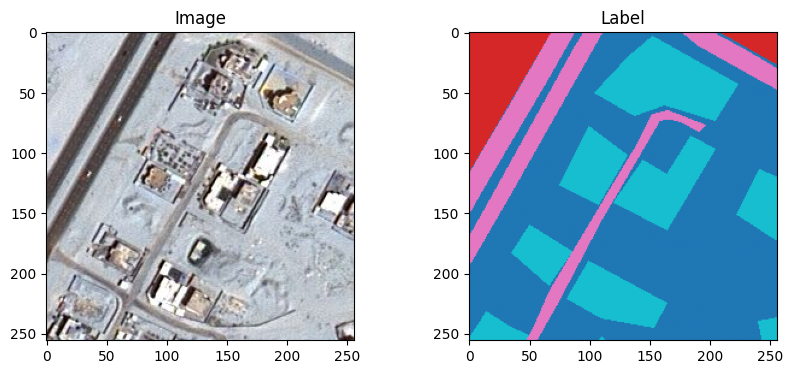

In [49]:
import random

idx = random.randint(0, len(image_patches)-1)

plt.figure(figsize=(10,4))

plt.subplot(1,2,1)
plt.title("Image")
plt.imshow(image_patches[idx])

plt.subplot(1,2,2)
plt.title("Label")
plt.imshow(label_patches[idx], cmap='tab10')

plt.show()


# NOTES: RGB → LABEL CONVERSION


 1. Why convert RGB masks?
 Original masks are color images (RGB),
 but deep learning models require class indices (0–5).

 2. What this step does:
 Converts each pixel color → corresponding class ID.

 Example:
 water (RGB) → 0
 land  (RGB) → 1


 3. Output format:
 Before → (256,256,3)
 After  → (256,256)






In [11]:
# Dataset + DataLoader

# 1 — Train / Validation Split
from sklearn.model_selection import train_test_split

X_train, X_val, y_train, y_val = train_test_split(
    image_patches, label_patches, test_size=0.2, random_state=42
)

print(len(X_train), len(X_val))



1044 261


In [12]:
# Albumentations Transform
import albumentations as A
from albumentations.pytorch import ToTensorV2

transform = A.Compose([
    A.HorizontalFlip(p=0.5),
    A.VerticalFlip(p=0.5),
    A.RandomRotate90(p=0.5),

    A.RandomBrightnessContrast(p=0.3),
    A.GaussNoise(p=0.2),
    A.Blur(p=0.2),
    A.RandomGamma(p=0.3),

    A.Normalize(mean=(0.485,0.456,0.406),
                std=(0.229,0.224,0.225)),
    ToTensorV2()
])

In [13]:
# 3 — Dataset Class
class SatelliteDataset(Dataset):
    def __init__(self, images, masks, transform=None):
        self.images = images
        self.masks = masks
        self.transform = transform

    def __len__(self):
        return len(self.images)

    def __getitem__(self, idx):
        image = self.images[idx]
        mask = self.masks[idx]

        if self.transform:
            aug = self.transform(image=image, mask=mask)
            image = aug["image"]
            mask = aug["mask"]

        return image, mask.long()

In [14]:
# 4 4 — Create Dataset Objects
train_dataset = SatelliteDataset(X_train, y_train, transform)
val_dataset = SatelliteDataset(X_val, y_val, transform)

In [15]:
# 5 — DataLoader
train_loader = DataLoader(train_dataset, batch_size=8, shuffle=True)
val_loader = DataLoader(val_dataset, batch_size=8, shuffle=False)

In [16]:
for images, masks in train_loader:
    print("Images shape:", images.shape)
    print("Masks shape:", masks.shape)
    break

Images shape: torch.Size([8, 3, 256, 256])
Masks shape: torch.Size([8, 256, 256])


[Batch, Channels, Height, Width]

[8, 3, 256, 256]

Masks
[Batch, Height, Width]
[8, 256, 256]


In [17]:
print(images.dtype)
print(masks.dtype)

torch.float32
torch.int64


In [18]:
# Check value range
print(images.min(), images.max())

tensor(-2.1179) tensor(2.6400)


In [19]:
# Check mask values
print(torch.unique(masks))

tensor([0, 1, 2, 3, 4, 5])


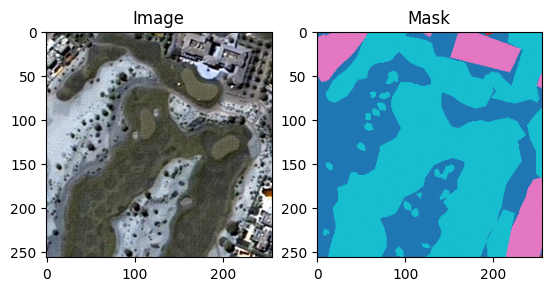

In [20]:
img = images[0].permute(1,2,0).cpu().numpy()

# undo normalization
mean = np.array([0.485,0.456,0.406])
std = np.array([0.229,0.224,0.225])

img = (img * std) + mean
img = np.clip(img, 0, 1)

mask = masks[0].cpu().numpy()

plt.subplot(1,2,1)
plt.imshow(img)
plt.title("Image")

plt.subplot(1,2,2)
plt.imshow(mask, cmap='tab10')
plt.title("Mask")

plt.show()

# RAW DATA → PATCHES → LABELS → TENSORS → BATCHES

# MODEL + TRAINING

In [21]:
# U-Net + ResNet34
!pip install segmentation-models-pytorch

   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 154.8/154.8 kB 6.4 MB/s eta 0:00:00


In [24]:
import torch
device = torch.device("cuda" if torch.cuda.is_available() else "cpu")

model = model.to(device)

print("Using device:", device)

Using device: cuda


In [25]:
import segmentation_models_pytorch as smp
import torch
model = smp.Unet(
    encoder_name="resnet34",
    encoder_weights="imagenet",
    in_channels=3,
    classes=6,
    decoder_dropout=0.2
)
model = model.to(device)

In [26]:
# Loss

import torch.nn as nn
import torch.nn.functional as F
import segmentation_models_pytorch as smp

ce_loss = nn.CrossEntropyLoss()
dice_loss = smp.losses.DiceLoss(mode="multiclass")

def combined_loss(pred, target):
    return 0.7 * ce_loss(pred, target) + 0.3 * dice_loss(pred, target)

 COMBINED LOSS


 CrossEntropyLoss:
 - handles multi-class classification
 - stable gradients

 DiceLoss:
 - improves segmentation quality
 - handles class imbalance

 Final loss = 0.7*CE + 0.3*Dice

In [27]:
# Optimizer
optimizer = torch.optim.Adam(
    model.parameters(),
    lr=1e-4,
    weight_decay=1e-5   # reduces overfitting
)

In [28]:
# Scheduler (stabilizes validation)
scheduler = torch.optim.lr_scheduler.ReduceLROnPlateau(
    optimizer,
    mode='min',
    patience=2,
    factor=0.5
)

# Training Loop

In [29]:
best_val_loss = float('inf')

epochs = 25
train_losses = []
val_losses = []

for epoch in range(epochs):

    # TRAIN
    model.train()
    train_loss = 0

    for images, masks in train_loader:
        images = images.to(device)
        masks = masks.to(device)

        outputs = model(images)
        loss = combined_loss(outputs, masks)

        optimizer.zero_grad()
        loss.backward()
        optimizer.step()

        train_loss += loss.item()

    avg_train_loss = train_loss / len(train_loader)

    # VALIDATION
    model.eval()
    val_loss = 0

    with torch.no_grad():
        for images, masks in val_loader:
            images = images.to(device)
            masks = masks.to(device)

            outputs = model(images)
            loss = combined_loss(outputs, masks)
            val_loss += loss.item()

    avg_val_loss = val_loss / len(val_loader)

    # STORE
    train_losses.append(avg_train_loss)
    val_losses.append(avg_val_loss)

    # SAVE BEST
    if avg_val_loss < best_val_loss:
        best_val_loss = avg_val_loss
        torch.save(model.state_dict(), "best_model.pth")
        print(" Best model saved")

    # SCHEDULER STEP
    scheduler.step(avg_val_loss)

    print(f"Epoch [{epoch+1}/{epochs}] "
          f"Train: {avg_train_loss:.4f} "
          f"Val: {avg_val_loss:.4f}")

 Best model saved
Epoch [1/25] Train: 0.9377 Val: 0.6592
 Best model saved
Epoch [2/25] Train: 0.7230 Val: 0.5600
 Best model saved
Epoch [3/25] Train: 0.6486 Val: 0.5361
 Best model saved
Epoch [4/25] Train: 0.6052 Val: 0.4884
 Best model saved
Epoch [5/25] Train: 0.5700 Val: 0.4608
Epoch [6/25] Train: 0.5514 Val: 0.4705
Epoch [7/25] Train: 0.5338 Val: 0.4682
 Best model saved
Epoch [8/25] Train: 0.5263 Val: 0.4354
Epoch [9/25] Train: 0.5177 Val: 0.4615
Epoch [10/25] Train: 0.4970 Val: 0.4512
 Best model saved
Epoch [11/25] Train: 0.4774 Val: 0.4269
Epoch [12/25] Train: 0.4795 Val: 0.4373
 Best model saved
Epoch [13/25] Train: 0.5063 Val: 0.4096
Epoch [14/25] Train: 0.4745 Val: 0.4176
Epoch [15/25] Train: 0.4707 Val: 0.4135
Epoch [16/25] Train: 0.4366 Val: 0.4113
 Best model saved
Epoch [17/25] Train: 0.4279 Val: 0.3837
Epoch [18/25] Train: 0.4175 Val: 0.3898
Epoch [19/25] Train: 0.4094 Val: 0.3855
 Best model saved
Epoch [20/25] Train: 0.3982 Val: 0.3818
Epoch [21/25] Train: 0.4179 V

In [30]:
model.load_state_dict(torch.load("best_model.pth"))

<All keys matched successfully>

In [31]:
# IoU function
def compute_iou(pred, target, num_classes=6):
    ious = []

    pred = pred.view(-1)
    target = target.view(-1)

    for cls in range(num_classes):
        pred_inds = (pred == cls)
        target_inds = (target == cls)

        intersection = (pred_inds & target_inds).sum().item()
        union = (pred_inds | target_inds).sum().item()

        if union == 0:
            continue

        iou = intersection / union
        ious.append(iou)

    return sum(ious) / len(ious)

In [32]:
# Evaluate model on validation set
model.eval()

total_iou = 0
count = 0

with torch.no_grad():
    for images, masks in val_loader:
        images = images.to(device)
        masks = masks.to(device)

        outputs = model(images)
        preds = torch.argmax(outputs, dim=1)

        iou = compute_iou(preds.cpu(), masks.cpu())
        total_iou += iou
        count += 1

mean_iou = total_iou / count

print("Mean IoU:", mean_iou)

Mean IoU: 0.6338534723475063


In [33]:
# Dice Score

def compute_dice(pred, target, num_classes=6):
    dices = []

    pred = pred.view(-1)
    target = target.view(-1)

    for cls in range(num_classes):
        pred_inds = (pred == cls)
        target_inds = (target == cls)

        intersection = (pred_inds & target_inds).sum().item()
        total = pred_inds.sum().item() + target_inds.sum().item()

        if total == 0:
            continue

        dice = (2 * intersection) / total
        dices.append(dice)

    return sum(dices) / len(dices)

In [34]:
# Evaluate Dice

total_dice = 0

with torch.no_grad():
    for images, masks in val_loader:
        images = images.to(device)
        masks = masks.to(device)

        outputs = model(images)
        preds = torch.argmax(outputs, dim=1)

        dice = compute_dice(preds.cpu(), masks.cpu())
        total_dice += dice

mean_dice = total_dice / count

print("Mean Dice:", mean_dice)

Mean Dice: 0.7251108724582714


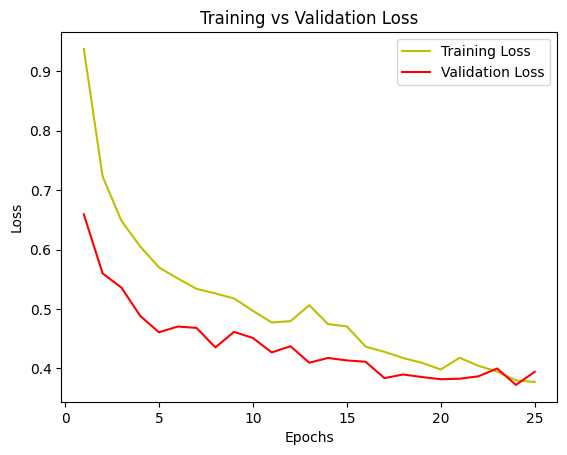

In [35]:
# Plot Loss Graph
import matplotlib.pyplot as plt

epochs = range(1, len(train_losses) + 1)

plt.plot(epochs, train_losses, 'y', label="Training Loss")
plt.plot(epochs, val_losses, 'r', label="Validation Loss")

plt.title("Training vs Validation Loss")
plt.xlabel("Epochs")
plt.ylabel("Loss")
plt.legend()
plt.show()

In [40]:
# Prediction + Visualization
import random

model.eval()

idx = random.randint(0, len(val_dataset)-1)

image, mask = val_dataset[idx]

image_input = image.unsqueeze(0).to(device)

with torch.no_grad():
    output = model(image_input)
    pred = torch.argmax(output, dim=1).squeeze(0)

In [41]:
# Convert image back
img = image.permute(1,2,0).cpu().numpy()

mean = [0.485,0.456,0.406]
std = [0.229,0.224,0.225]

img = img * std + mean
img = img.clip(0,1)

mask = mask.cpu().numpy()
pred = pred.cpu().numpy()

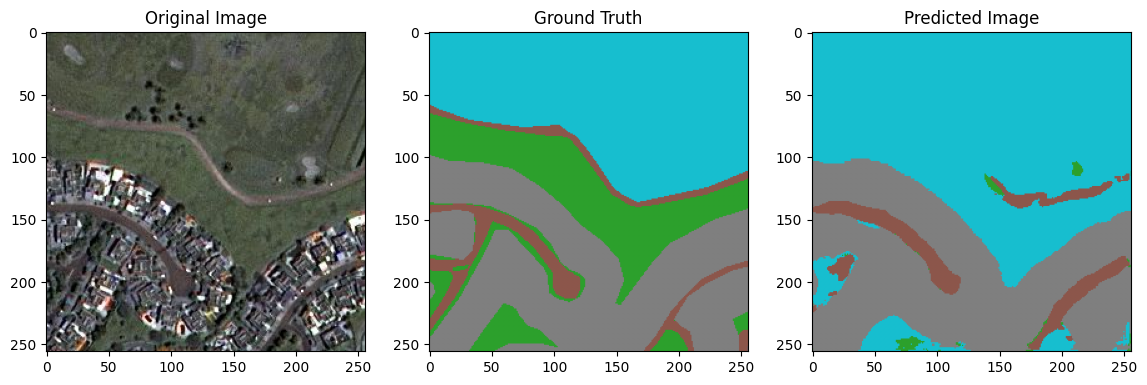

In [42]:
# Final Plot
plt.figure(figsize=(14,6))

plt.subplot(1,3,1)
plt.title("Original Image")
plt.imshow(img)

plt.subplot(1,3,2)
plt.title("Ground Truth")
plt.imshow(mask, cmap='tab10')

plt.subplot(1,3,3)
plt.title("Predicted Image")
plt.imshow(pred, cmap='tab10')

plt.show()

In [47]:
import os
import random
import numpy as np
import matplotlib.pyplot as plt


os.makedirs("results", exist_ok=True)

model.eval()

saved = 0
target_samples = 5
for i in range(50):

    idx = random.randint(0, len(val_dataset)-1)
    image, mask = val_dataset[idx]

    # check richness
    unique_classes = len(np.unique(mask.numpy()))

    if unique_classes < 3:
        continue

    # prediction
    image_input = image.unsqueeze(0).to(device)

    with torch.no_grad():
        output = model(image_input)
        pred = torch.argmax(output, dim=1).squeeze(0)

    # prepare image
    img = image.permute(1,2,0).cpu().numpy()
    img = img * [0.229,0.224,0.225] + [0.485,0.456,0.406]
    img = np.clip(img, 0, 1)

    mask_np = mask.cpu().numpy()
    pred_np = pred.cpu().numpy()

    # save combined image
    plt.figure(figsize=(12,4))

    plt.subplot(1,3,1)
    plt.title("Input")
    plt.imshow(img)

    plt.subplot(1,3,2)
    plt.title("GT")
    plt.imshow(mask_np, cmap='tab10')

    plt.subplot(1,3,3)
    plt.title("Pred")
    plt.imshow(pred_np, cmap='tab10')

    plt.tight_layout()
    plt.savefig(f"results/result_{saved}.png")
    plt.close()

    saved += 1

    if saved == target_samples:
        break

print("Saved images:", saved)

Saved images: 5


In [48]:
from google.colab import files
import shutil

shutil.make_archive("results_zip", 'zip', "results")
files.download("results_zip.zip")

<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>